# Final Model: Random Forest (Simplified Pipeline)

**Philosophy**: Minimal tuning for maximum robustness. Random Forest performs best with conservative regularization and simple feature selection.

**Key Changes from Full Pipeline:**
- **Simpler feature selection**: Top features by importance only (no greedy forward selection)
- **Stricter regularization**: Smaller max_depth (≤10), larger min_samples_leaf (≥5)
- **Lighter tuning**: 5-10 Optuna trials instead of 30
- **More conservative penalty**: λ=0.5 to avoid overfitting

**Dataset**: `df_artists_final.csv` (759 artists × 26 features)  
**Target**: `top_20_hitmaker` (binary)  
**Split**: 80/20 stratified

In [1]:
import shap
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('✓ All imports successful')

✓ All imports successful


## Configuration

In [2]:
# Conservative configuration for RF
LAM             = 0.5      # More conservative penalty on gap (vs. 0.3)
N_SPLITS        = 5        # 5-fold stratified CV
N_TRIALS        = 8        # Minimal tuning (vs. 15-30)
RANDOM_STATE    = 42

# Conservative regularization bounds
MAX_DEPTH_BOUNDS    = (2, 10)      # Smaller max_depth (vs. 2-15)
MIN_SAMPLES_BOUNDS  = (5, 15)      # Balanced min_samples_leaf (reduced from 10-30) → better recall
TOP_N_FEATURES      = 12           # Keep top 12 features by importance
PRECISION_FLOOR     = 0.60         # Enforce minimum precision in threshold tuning (reduced from 0.65)

# Centrality features
CENTRALITY_COLS = [
    'betweenness_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]

print(f'Configuration:')
print(f'  Penalty lambda: {LAM} (conservative)')
print(f'  Optuna trials: {N_TRIALS} (minimal)')
print(f'  Max depth: {MAX_DEPTH_BOUNDS[0]}-{MAX_DEPTH_BOUNDS[1]}')
print(f'  Min samples leaf: {MIN_SAMPLES_BOUNDS[0]}-{MIN_SAMPLES_BOUNDS[1]} (balanced)')
print(f'  Precision floor: {PRECISION_FLOOR} (threshold tuning constraint)')
print(f'  Top N features: {TOP_N_FEATURES}')

Configuration:
  Penalty lambda: 0.5 (conservative)
  Optuna trials: 8 (minimal)
  Max depth: 2-10
  Min samples leaf: 5-15 (balanced)
  Precision floor: 0.6 (threshold tuning constraint)
  Top N features: 12


## Data Loading & Preprocessing

In [3]:
# Load data
df = pd.read_csv('../df_artists_final.csv', index_col=0).reset_index()
X = df.drop(columns=['top_20_hitmaker'])
y = df['top_20_hitmaker']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Data shape: {df.shape}')
print(f'Train / Test: {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'\nClass balance:')
print(y.value_counts(normalize=True).round(3))

# Preprocessing: Imputation only
imputer = SimpleImputer(strategy='median')
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index,
)
X_test_clean = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index,
)

print(f'\nPreprocessing complete')

Data shape: (759, 27)
Train / Test: 607 / 152
Features: 26

Class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Preprocessing complete


## Step 1: Feature Importance (Baseline Model)

Train baseline RF with conservative defaults to identify important features.

In [4]:
print(f'\n{"="*60}')
print(f'  STEP 1: Feature Importance (Conservative Baseline)')
print(f'{"="*60}')

# Baseline model with strict regularization
baseline_params = {
    'n_estimators': 200,
    'max_depth': 8,
    'min_samples_leaf': 5,
    'max_features': 'sqrt',
}

baseline_model = RandomForestClassifier(
    **baseline_params,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1,
)

# Compute CV permutation importance
print('\nComputing CV permutation importance...')
fold_importances = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_clean, y_train)):
    X_tr, X_v = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
    y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
    model = RandomForestClassifier(**baseline_params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_tr, y_tr)
    perm = permutation_importance(
        model, X_v, y_v,
        n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc',
    )
    fold_importances.append(perm.importances_mean)

mean_imp = np.mean(fold_importances, axis=0)
std_imp = np.std(fold_importances, axis=0)
perm_df = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': mean_imp,
    'Std': std_imp,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f'\nTop 15 features by importance:')
print(perm_df.head(15).to_string(index=False))


  STEP 1: Feature Importance (Conservative Baseline)

Computing CV permutation importance...

Top 15 features by importance:
                                     Feature  Importance      Std
#_of_charting_songs_through_first_top_20_hit    0.088242 0.004719
       betweenness_centrality_top20_rolling5    0.017053 0.009449
                          #_of_genres_artist    0.015153 0.004368
                            artist_genre_Pop    0.009017 0.004628
       eigenvector_centrality_top20_rolling5    0.006959 0.008348
              years_through_first_top_20_hit    0.006711 0.004945
harmonic_closeness_centrality_top20_rolling5    0.006408 0.006264
                  artist_genre_R&B/Soul/Funk    0.004286 0.002113
                    artist_genre_Hip Hop/Rap    0.002486 0.001894
                  artist_genre_Punk/Hardcore    0.001417 0.001503
                           artist_genre_Jazz    0.000793 0.000430
                          artist_genre_Metal    0.000507 0.000911
                

## Step 2: Genre Consolidation

In [5]:
all_genre_cols = [c for c in X_train_clean.columns if c.startswith('artist_genre_')]
genre_imp = perm_df.set_index('Feature')['Importance']
genre_vals = genre_imp[[c for c in all_genre_cols if c in genre_imp.index]]
genre_mean = genre_vals.mean()

high_signal = [c for c in all_genre_cols if genre_imp.get(c, 0) > genre_mean]
low_signal = [c for c in all_genre_cols if c not in high_signal]

# Consolidate
X_tr_cons = X_train_clean.drop(columns=low_signal).copy()
X_te_cons = X_test_clean.drop(columns=low_signal).copy()

if low_signal:
    X_tr_cons['artist_genre_other'] = (X_train_clean[low_signal].sum(axis=1) > 0).astype(int)
    X_te_cons['artist_genre_other'] = (X_test_clean[low_signal].sum(axis=1) > 0).astype(int)

print(f'Genre consolidation:')
print(f'  Kept {len(high_signal)} genres: {[c.replace("artist_genre_", "") for c in high_signal]}')
print(f'  Merged {len(low_signal)} → artist_genre_other')
print(f'  Features after consolidation: {X_tr_cons.shape[1]}')

Genre consolidation:
  Kept 4 genres: ['Hip Hop/Rap', 'Pop', 'Punk/Hardcore', 'R&B/Soul/Funk']
  Merged 15 → artist_genre_other
  Features after consolidation: 12


## Step 3: Simple Feature Selection

Keep top N features by importance (no greedy selection).

In [6]:
# Recompute importance on consolidated features
print(f'\nRe-ranking features (consolidated set)...')

fold_importances_cons = []
for train_idx, val_idx in skf.split(X_tr_cons, y_train):
    X_tr, X_v = X_tr_cons.iloc[train_idx], X_tr_cons.iloc[val_idx]
    y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
    model = RandomForestClassifier(**baseline_params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_tr, y_tr)
    perm = permutation_importance(
        model, X_v, y_v,
        n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc',
    )
    fold_importances_cons.append(perm.importances_mean)

mean_imp_cons = np.mean(fold_importances_cons, axis=0)
perm_df_cons = pd.DataFrame({
    'Feature': X_tr_cons.columns,
    'Importance': mean_imp_cons,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Select top N
top_features = perm_df_cons.head(TOP_N_FEATURES)['Feature'].tolist()
X_train_final = X_tr_cons[top_features]
X_test_final = X_te_cons[top_features]

print(f'\nSelected top {TOP_N_FEATURES} features:')
print(perm_df_cons.head(TOP_N_FEATURES).to_string(index=False))
print(f'\nFinal feature set: {X_train_final.shape[1]} features')


Re-ranking features (consolidated set)...

Selected top 12 features:
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit    0.114110
       betweenness_centrality_top20_rolling5    0.020078
                          #_of_genres_artist    0.016753
                            artist_genre_Pop    0.013836
              years_through_first_top_20_hit    0.009468
       eigenvector_centrality_top20_rolling5    0.009322
harmonic_closeness_centrality_top20_rolling5    0.007300
                  artist_genre_R&B/Soul/Funk    0.002647
                    artist_genre_Hip Hop/Rap    0.002225
                  artist_genre_Punk/Hardcore    0.000429
                          artist_genre_other   -0.001494
 top_20_hit_song_#_wks_on_chart_any_position   -0.001605

Final feature set: 12 features


## Step 4: Hyperparameter Tuning (Light)

Minimal Optuna tuning on final feature set with strict regularization bounds.

In [7]:
def build_rf(params):
    return RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params.get('max_depth', 8),
        min_samples_leaf=params.get('min_samples_leaf', 5),
        max_features=params.get('max_features', 'sqrt'),
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def optuna_objective(trial, X, y, skf, lam):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 150, 350),
        'max_depth':        trial.suggest_int('max_depth', MAX_DEPTH_BOUNDS[0], MAX_DEPTH_BOUNDS[1]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', MIN_SAMPLES_BOUNDS[0], MIN_SAMPLES_BOUNDS[1]),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    
    fold_val_auc, fold_train_auc = [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = build_rf(params)
        model.fit(X_tr, y_tr)
        fold_val_auc.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_train_auc.append(roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1]))
    
    val_auc = np.mean(fold_val_auc)
    gap = np.mean(fold_train_auc) - val_auc
    return val_auc - lam * gap

def cv_evaluate(X, y, params, skf):
    fold_val_auc, fold_train_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = build_rf(params)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        proba_tr = model.predict_proba(X_tr)[:, 1]
        fold_val_auc.append(roc_auc_score(y_val, proba))
        fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
        fold_logloss.append(log_loss(y_val, proba))
        fold_brier.append(brier_score_loss(y_val, proba))
    
    return {
        'CV AUC': np.mean(fold_val_auc),
        'CV AUC Std': np.std(fold_val_auc),
        'Train AUC': np.mean(fold_train_auc),
        'Overfit Gap': np.mean(fold_train_auc) - np.mean(fold_val_auc),
        'Logloss': np.mean(fold_logloss),
        'BrierScore': np.mean(fold_brier),
    }

print(f'\n{"="*60}')
print(f'  STEP 4: Light Hyperparameter Tuning')
print(f'  {N_TRIALS} trials, λ={LAM}')
print(f'{"="*60}')

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(
    lambda trial: optuna_objective(trial, X_train_final, y_train, skf, LAM),
    n_trials=N_TRIALS, show_progress_bar=True,
)

params_final = study.best_params
cv_result_final = cv_evaluate(X_train_final, y_train, params_final, skf)

print(f'\nBest parameters:')
for k, v in params_final.items():
    print(f'  {k}: {v}')
print(f'\nCV AUC: {cv_result_final["CV AUC"]:.4f} ± {cv_result_final["CV AUC Std"]:.4f}')
print(f'Overfit Gap: {cv_result_final["Overfit Gap"]:.4f}')


  STEP 4: Light Hyperparameter Tuning
  8 trials, λ=0.5


  0%|          | 0/8 [00:00<?, ?it/s]


Best parameters:
  n_estimators: 181
  max_depth: 2
  min_samples_leaf: 14
  max_features: log2

CV AUC: 0.7509 ± 0.0291
Overfit Gap: 0.0299


## Step 5: Centrality Ablation (Optional)

Test if removing centrality features improves robustness.

In [8]:
from itertools import combinations as itercombs

print(f'\nCentrality Ablation Analysis')
print('─' * 60)

cent = [c for c in CENTRALITY_COLS if c in X_train_final.columns]
short_cent = lambda cols: [c.replace('_centrality_top20_rolling5', '') for c in cols]

if not cent:
    print('  No centrality features in final set')
    centrality_kept = []
else:
    rows = []
    for n_drop in range(len(cent) + 1):
        for dropped in itercombs(cent, n_drop):
            dropped = list(dropped)
            feats = [c for c in X_train_final.columns if c not in dropped]
            res = cv_evaluate(X_train_final[feats], y_train, params_final, skf)
            rows.append({
                '_dropped_cols': dropped,
                'Dropped': ', '.join(short_cent(dropped)) or 'none (baseline)',
                'CV AUC': round(res['CV AUC'], 4),
                'Gap': round(res['Overfit Gap'], 4),
            })
    
    df_abl = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
    print('  Ablation results:')
    print(df_abl[['Dropped', 'CV AUC', 'Gap']].head(3).to_string(index=False))
    
    best = df_abl.iloc[0]
    to_drop = best['_dropped_cols']
    
    if to_drop:
        X_train_final = X_train_final.drop(columns=to_drop)
        X_test_final = X_test_final.drop(columns=to_drop)
        cv_result_final = cv_evaluate(X_train_final, y_train, params_final, skf)
        print(f'  → Dropped {short_cent(to_drop)}')
    else:
        print(f'  → Keep all')
    
    centrality_kept = [c for c in cent if c not in to_drop]

print(f'\nFinal feature count: {X_train_final.shape[1]}')


Centrality Ablation Analysis
────────────────────────────────────────────────────────────
  Ablation results:
                                     Dropped  CV AUC    Gap
             harmonic_closeness, eigenvector  0.7586 0.0262
                    betweenness, eigenvector  0.7562 0.0269
betweenness, harmonic_closeness, eigenvector  0.7556 0.0224
  → Dropped ['harmonic_closeness', 'eigenvector']

Final feature count: 10


## Step 6: Final Model Training & Evaluation

In [9]:
print(f'\n{"="*60}')
print(f'Final Model Training & Evaluation')
print(f'{"="*60}')

# Fit on full training set
model_final = build_rf(params_final)
model_final.fit(X_train_final, y_train)

# Test evaluation
y_proba_test = model_final.predict_proba(X_test_final)[:, 1]
y_proba_train = model_final.predict_proba(X_train_final)[:, 1]

test_auc = roc_auc_score(y_test, y_proba_test)
train_auc = roc_auc_score(y_train, y_proba_train)
gap = train_auc - test_auc
logloss = log_loss(y_test, y_proba_test)
brier = brier_score_loss(y_test, y_proba_test)

print(f'\nTest Set Performance:')
print(f'  Test AUC: {test_auc:.4f}')
print(f'  Train AUC: {train_auc:.4f}')
print(f'  Overfit Gap: {gap:.4f}')
print(f'  Log Loss: {logloss:.4f}')
print(f'  Brier Score: {brier:.4f}')


Final Model Training & Evaluation

Test Set Performance:
  Test AUC: 0.7729
  Train AUC: 0.7809
  Overfit Gap: 0.0080
  Log Loss: 0.5967
  Brier Score: 0.2045


In [10]:
total_leaves = sum(tree.tree_.n_leaves for tree in model_final.estimators_)
avg_leaves   = total_leaves / len(model_final.estimators_)
print(f'Total leaves across all trees : {total_leaves}')
print(f'Average leaves per tree        : {avg_leaves:.1f}')
print(f'Max possible leaves (2^depth)  : {2**model_final.max_depth * len(model_final.estimators_)}')

Total leaves across all trees : 717
Average leaves per tree        : 4.0
Max possible leaves (2^depth)  : 724


## Step 7: OOF Threshold Tuning

In [12]:
print(f'\nTuning decision threshold on OOF predictions...')

# OOF predictions
oof_proba = np.zeros(len(y_train))
for train_idx, val_idx in skf.split(X_train_final, y_train):
    X_tr, X_v = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    m = build_rf(params_final)
    m.fit(X_tr, y_tr)
    oof_proba[val_idx] = m.predict_proba(X_v)[:, 1]

# Find optimal threshold with PRECISION CONSTRAINT
thresholds = np.arange(0.05, 0.95, 0.01)
f1s = np.array([f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
precs = np.array([precision_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])

# Enforce precision >= 0.65 floor, then maximize F1 within that constraint
valid_mask = precs >= PRECISION_FLOOR
if valid_mask.any():
    best_idx = np.argmax(np.where(valid_mask, f1s, -np.inf))
else:
    # Fallback: use highest precision, then highest F1
    best_idx = np.argmax(precs)

chosen_thresh = round(thresholds[best_idx], 2)

# Test metrics
y_pred_final = (y_proba_test >= chosen_thresh).astype(int)
prec_final = precision_score(y_test, y_pred_final, zero_division=0)
rec_final = recall_score(y_test, y_pred_final, zero_division=0)
f1_final = f1_score(y_test, y_pred_final, zero_division=0)

print(f'\nOptimal threshold: {chosen_thresh}')
print(f'Test set metrics at threshold={chosen_thresh}:')
print(f'  Precision: {prec_final:.3f}')
print(f'  Recall: {rec_final:.3f}')
print(f'  F1: {f1_final:.3f}')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f'\nConfusion Matrix:')
print(f'  TP={tp}, FP={fp}, FN={fn}, TN={tn}')


Tuning decision threshold on OOF predictions...

Optimal threshold: 0.5
Test set metrics at threshold=0.5:
  Precision: 0.627
  Recall: 0.712
  F1: 0.667

Confusion Matrix:
  TP=47, FP=28, FN=19, TN=58



Threshold Tuning: Precision-Recall-F1 Tradeoff
────────────────────────────────────────────────────────────


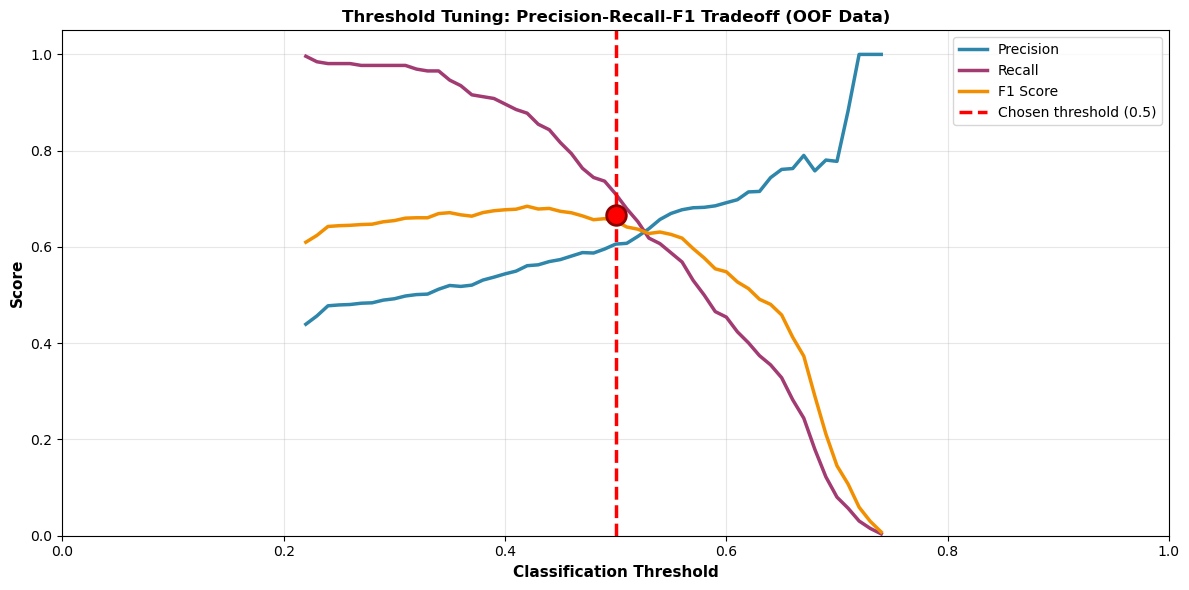

Current threshold: 0.5 → Precision=0.627, Recall=0.712, F1=0.667


In [13]:
# Threshold tuning visualization
print('\nThreshold Tuning: Precision-Recall-F1 Tradeoff')
print('─' * 60)

# Compute metrics at different thresholds
thresholds_viz = np.linspace(0, 1, 101)
precisions_viz = []
recalls_viz = []
f1_scores_viz = []

for thresh in thresholds_viz:
    y_pred_thresh = (oof_proba >= thresh).astype(int)
    if y_pred_thresh.sum() == 0 or y_pred_thresh.sum() == len(y_pred_thresh):
        precisions_viz.append(np.nan)
        recalls_viz.append(np.nan)
        f1_scores_viz.append(np.nan)
    else:
        precisions_viz.append(precision_score(y_train.values, y_pred_thresh, zero_division=0))
        recalls_viz.append(recall_score(y_train.values, y_pred_thresh, zero_division=0))
        f1_scores_viz.append(f1_score(y_train.values, y_pred_thresh, zero_division=0))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds_viz, precisions_viz, lw=2.5, label='Precision', color='#2E86AB')
ax.plot(thresholds_viz, recalls_viz, lw=2.5, label='Recall', color='#A23B72')
ax.plot(thresholds_viz, f1_scores_viz, lw=2.5, label='F1 Score', color='#F18F01')

# Mark chosen threshold
ax.axvline(x=chosen_thresh, color='red', linewidth=2.5, linestyle='--', 
           label=f'Chosen threshold ({chosen_thresh})')
ax.scatter([chosen_thresh], [f1_final], s=200, color='red', zorder=5, 
           marker='o', edgecolors='darkred', linewidth=2)

ax.set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Threshold Tuning: Precision-Recall-F1 Tradeoff (OOF Data)', 
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print(f'Current threshold: {chosen_thresh} → Precision={prec_final:.3f}, Recall={rec_final:.3f}, F1={f1_final:.3f}')

## Model Summary

In [14]:
print(f'\n{"="*80}')
print(f'FINAL RANDOM FOREST MODEL (SIMPLIFIED)')
print(f'{"="*80}')

print(f'\n**Pipeline Philosophy:**')
print(f'  • Minimal tuning: {N_TRIALS} Optuna trials')
print(f'  • Simple feature selection: top {TOP_N_FEATURES} features by importance')
print(f'  • Conservative regularization: max_depth≤{MAX_DEPTH_BOUNDS[1]}, min_leaf≥{MIN_SAMPLES_BOUNDS[0]}')
print(f'  • Strong penalty on gap: λ={LAM}')

print(f'\n**Model Specification:**')
print(f'  n_estimators: {params_final["n_estimators"]}')
print(f'  max_depth: {params_final.get("max_depth")}')
print(f'  min_samples_leaf: {params_final.get("min_samples_leaf")}')
print(f'  max_features: {params_final.get("max_features")}')
print(f'  class_weight: balanced')

print(f'\n**Feature Set:**')
print(f'  Total: {X_train_final.shape[1]} features (from 26 original)')
print(f'  Centrality: {len(centrality_kept)} kept')

print(f'\n**CV Performance:**')
print(f'  CV AUC: {cv_result_final["CV AUC"]:.4f} ± {cv_result_final["CV AUC Std"]:.4f}')
print(f'  Overfit Gap: {cv_result_final["Overfit Gap"]:.4f}')

print(f'\n**Test Set Performance:**')
print(f'  AUC: {test_auc:.4f}')
print(f'  Precision: {prec_final:.3f}')
print(f'  Recall: {rec_final:.3f}')
print(f'  F1: {f1_final:.3f}')
print(f'  Log Loss: {logloss:.4f}')
print(f'  Brier Score: {brier:.4f}')

print(f'\n{"="*80}')


FINAL RANDOM FOREST MODEL (SIMPLIFIED)

**Pipeline Philosophy:**
  • Minimal tuning: 8 Optuna trials
  • Simple feature selection: top 12 features by importance
  • Conservative regularization: max_depth≤10, min_leaf≥5
  • Strong penalty on gap: λ=0.5

**Model Specification:**
  n_estimators: 181
  max_depth: 2
  min_samples_leaf: 14
  max_features: log2
  class_weight: balanced

**Feature Set:**
  Total: 10 features (from 26 original)
  Centrality: 1 kept

**CV Performance:**
  CV AUC: 0.7586 ± 0.0336
  Overfit Gap: 0.0262

**Test Set Performance:**
  AUC: 0.7729
  Precision: 0.627
  Recall: 0.712
  F1: 0.667
  Log Loss: 0.5967
  Brier Score: 0.2045



## SHAP Feature Importance


Computing SHAP values...

Top 10 Features (SHAP):
──────────────────────────────────────────────────────────────────────
#_of_charting_songs_through_first_top_20_hit  0.08379   -0.00312
betweenness_centrality_top20_rolling5     0.04579   -0.00395
artist_genre_Hip Hop/Rap                  0.02839   -0.00100
#_of_genres_artist                        0.02030   -0.00020
artist_genre_Pop                          0.01253   -0.00035
top_20_hit_song_#_wks_on_chart_any_position  0.01101   -0.00040
artist_genre_R&B/Soul/Funk                0.00770   -0.00027
artist_genre_other                        0.00411    0.00003
years_through_first_top_20_hit            0.00350   -0.00009
artist_genre_Punk/Hardcore                0.00015    0.00001


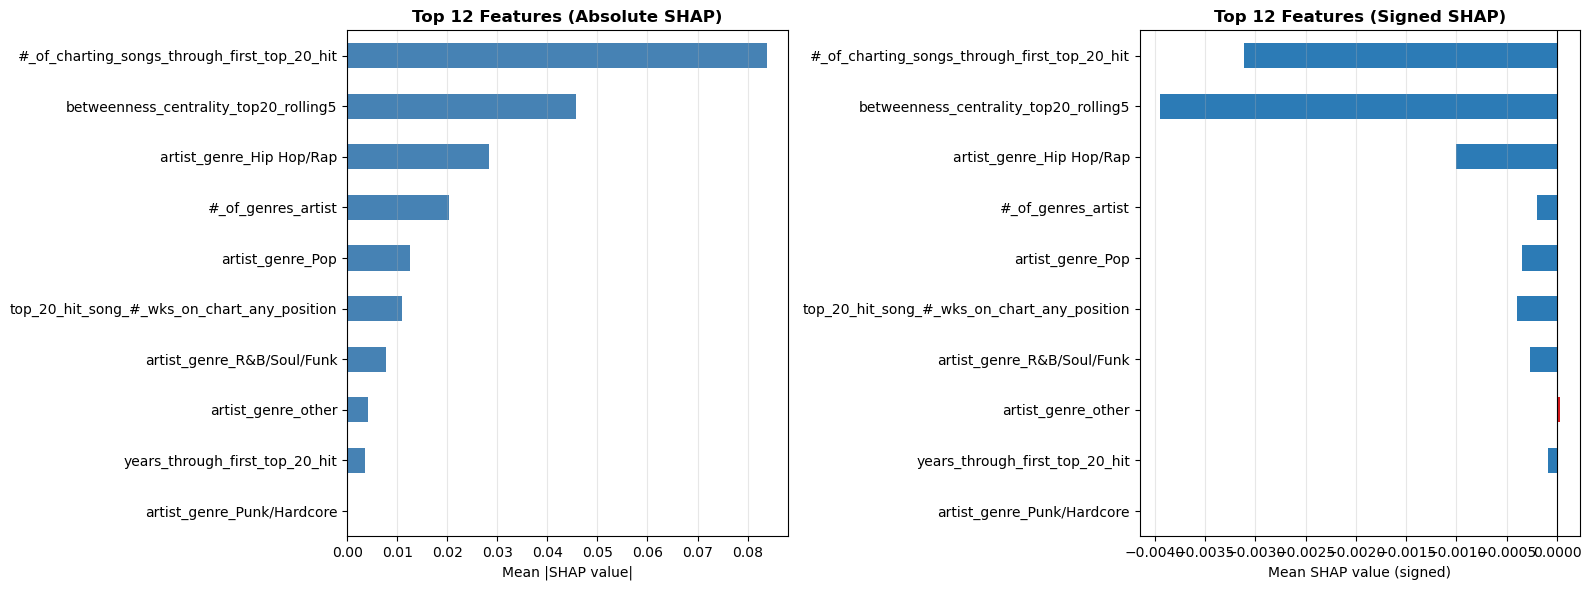


✓ SHAP complete


In [15]:
print('\nComputing SHAP values...')
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_train_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_final.columns).sort_values(ascending=False)
shap_signed = pd.Series(shap_values.mean(axis=0), index=X_train_final.columns).sort_values(ascending=False, key=abs)

print('\nTop 10 Features (SHAP):')
print('─' * 70)
for feat in shap_abs.head(10).index:
    print(f'{feat:<40} {shap_abs[feat]:>8.5f}  {shap_signed[feat]:>9.5f}')

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
shap_abs.head(12).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Mean |SHAP value|')
ax1.set_title('Top 12 Features (Absolute SHAP)', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
shap_abs_top12 = shap_abs.head(12)
shap_signed_top12 = shap_signed[shap_abs_top12.index]
colors_signed = ['#d7191c' if x > 0 else '#2c7bb6' for x in shap_signed_top12]
shap_signed_top12.plot(kind='barh', ax=ax2, color=colors_signed)
ax2.set_xlabel('Mean SHAP value (signed)')
ax2.set_title('Top 12 Features (Signed SHAP)', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('\n✓ SHAP complete')

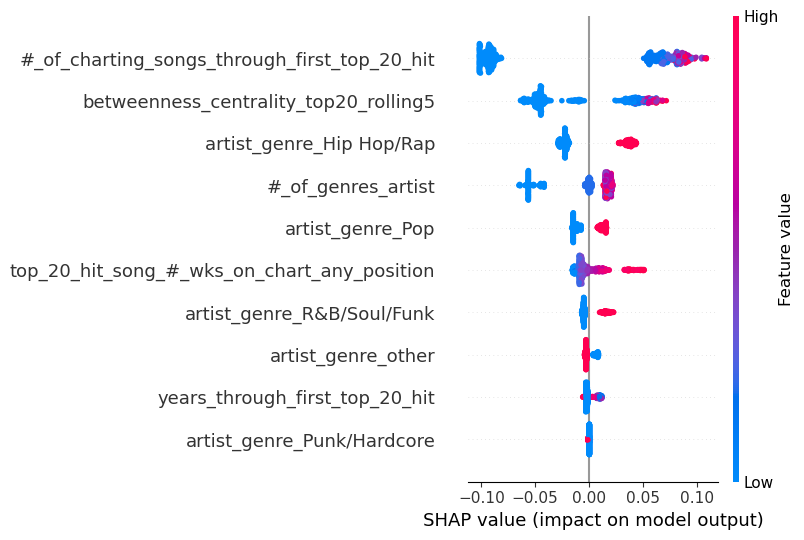

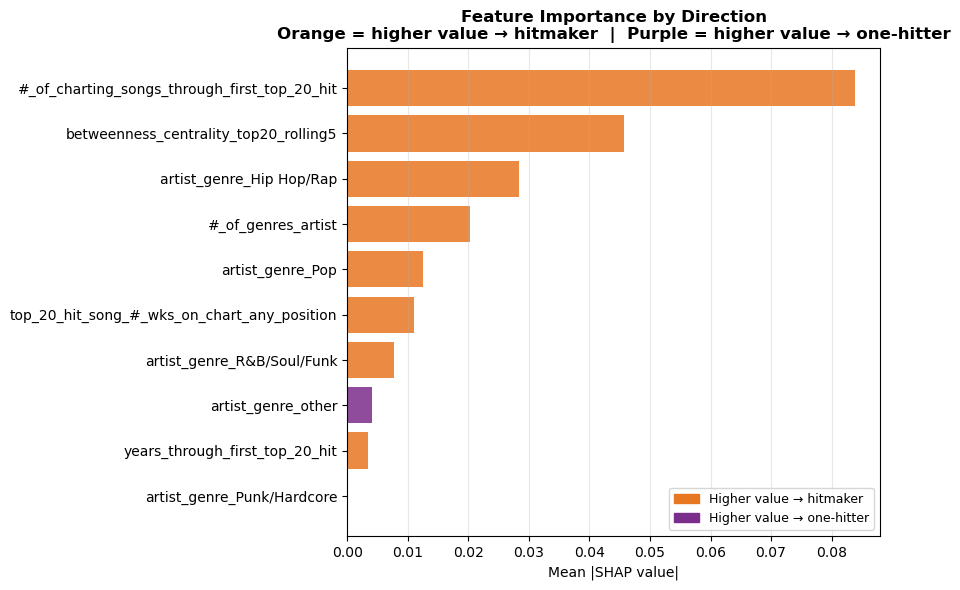

In [18]:
# Beeswarm
shap.summary_plot(shap_values, X_train_final, plot_type='dot', show=True)

# Direction via correlation between feature value and SHAP value
shap_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_final.columns).sort_values()

correlations = pd.Series({
    feat: np.corrcoef(X_train_final[feat], shap_values[:, i])[0, 1]
    for i, feat in enumerate(X_train_final.columns)
})

colors = ['#E87722' if correlations[f] > 0 else '#7B2D8B' for f in shap_abs.index]

fig, ax = plt.subplots(figsize=(9, 0.45 * len(shap_abs) + 1.5))
ax.barh(shap_abs.index, shap_abs.values, color=colors, alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance by Direction\n'
             'Orange = higher value → hitmaker  |  Purple = higher value → one-hitter',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E87722', label='Higher value → hitmaker'),
                   Patch(color='#7B2D8B', label='Higher value → one-hitter')],
          fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


## Model Diagnostics

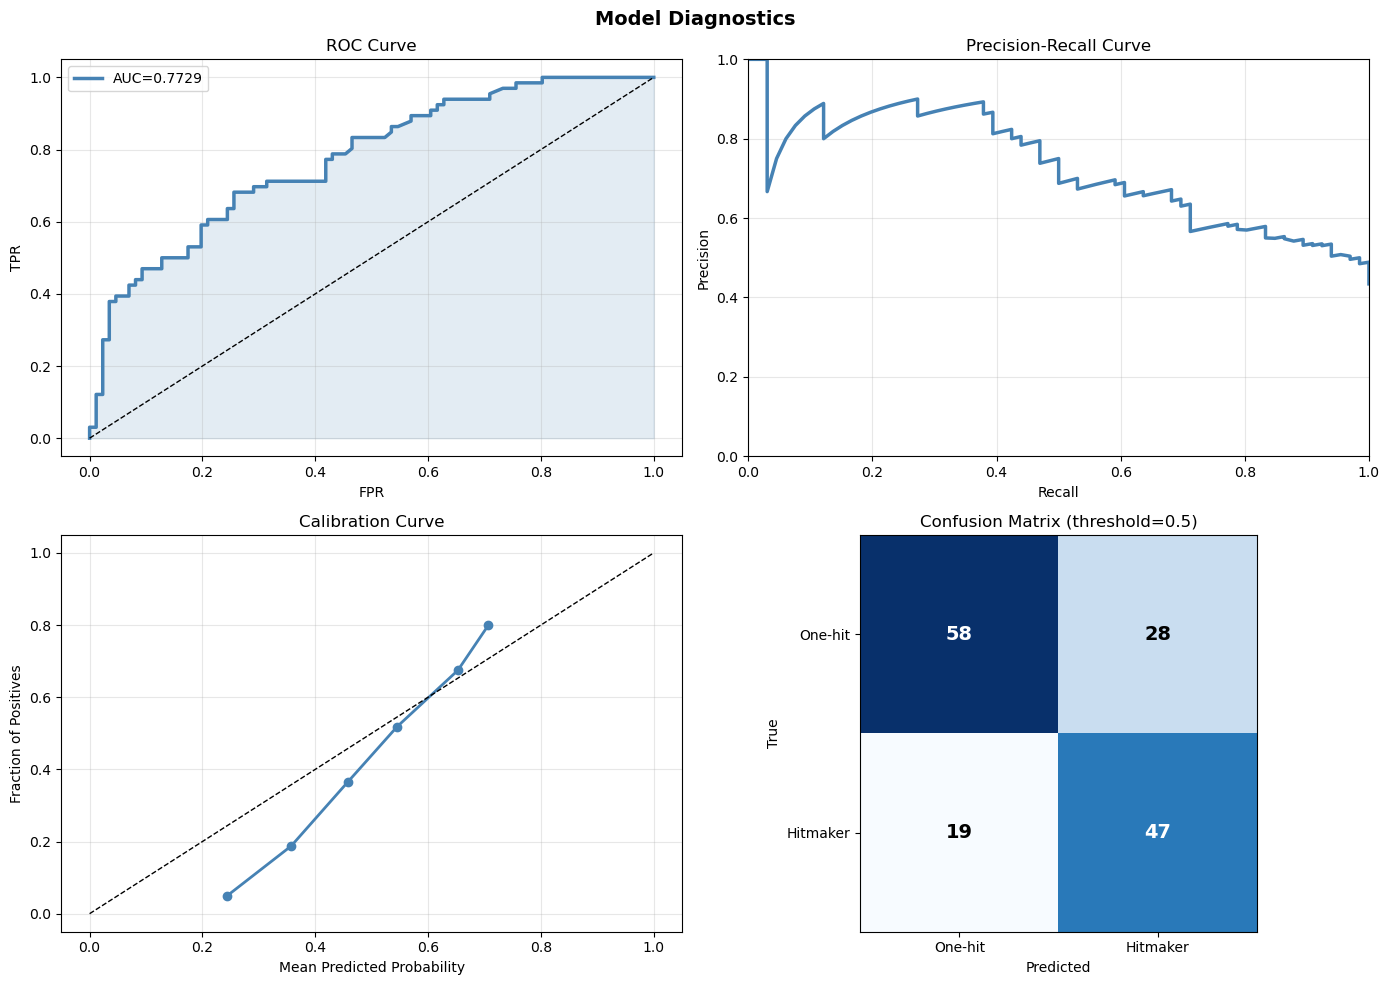

✓ Diagnostics complete


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Diagnostics', fontsize=14, fontweight='bold')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[0, 0].plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC={test_auc:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].fill_between(fpr, tpr, alpha=0.15, color='steelblue')
axes[0, 0].set_xlabel('FPR')
axes[0, 0].set_ylabel('TPR')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# P-R
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)
axes[0, 1].plot(rec, prec, lw=2.5, color='steelblue')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1)

# Calibration
frac_pos, mean_pred = calibration_curve(y_test, y_proba_test, n_bins=10)
axes[1, 0].plot(mean_pred, frac_pos, marker='o', lw=2, color='steelblue')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve')
axes[1, 0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
im = axes[1, 1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['One-hit', 'Hitmaker'])
axes[1, 1].set_yticklabels(['One-hit', 'Hitmaker'])
axes[1, 1].set_ylabel('True')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_title(f'Confusion Matrix (threshold={chosen_thresh})')
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black',
                        fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('✓ Diagnostics complete')

In [ ]:
import pickle

model_artifacts = {
    'model': model_final,
    'imputer': imputer,
    'feature_names': list(X_train_final.columns),
    'threshold': chosen_thresh,
    'params': params_final,
    'performance': {
        'test_auc': test_auc,
        'precision': prec_final,
        'recall': rec_final,
        'f1': f1_final,
    },
}

with open('final_rf_model_simplified.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print('✓ Model saved to final_rf_model_simplified.pkl')

✓ Model saved to final_rf_model_simplified.pkl
